Linear Trend: y = 226.19 + 11.0383x
Polynomial Trend: y = 314.47 + 11.0383x + -0.6970x^2


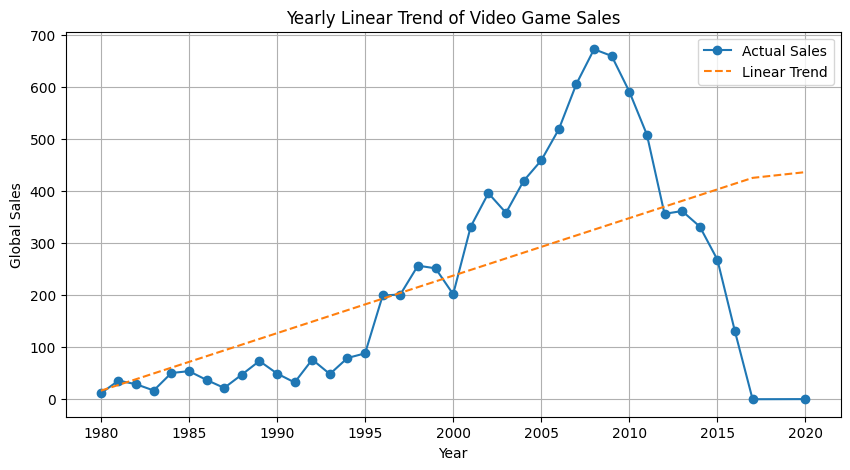

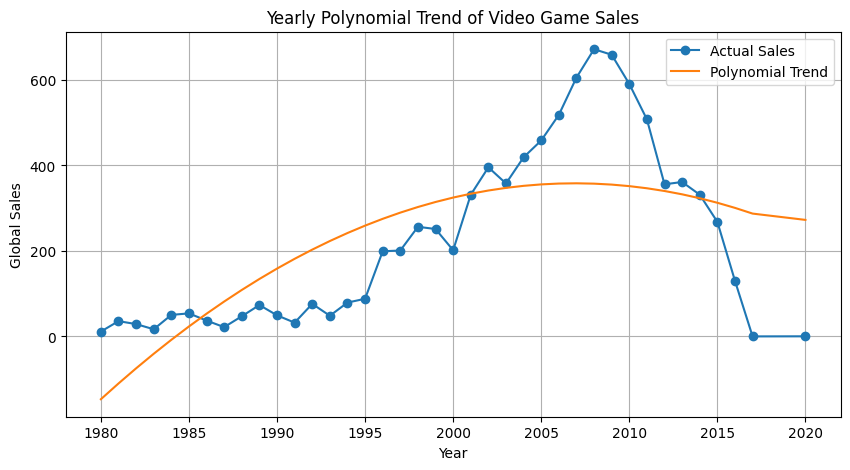

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
data = pd.read_csv('/content/Video_Games_Sales.csv')

# Remove missing values
data = data.dropna(subset=['Year_of_Release'])

# Convert year column into integer
data['Year_of_Release'] = data['Year_of_Release'].astype(int)

# Resample Yearly Total Sales
resampled_data = data.groupby('Year_of_Release')['Global_Sales'].sum().to_frame()

# Reset index
resampled_data = resampled_data.reset_index()

# Create Year index for trend calculation
resampled_data['Year_Num'] = range(len(resampled_data))

# Prepare Data
X = resampled_data['Year_Num'].tolist()
values = resampled_data['Global_Sales'].tolist()

# Center X values
X = [i - X[len(X)//2] for i in X]

x2 = [i**2 for i in X]
xy = [i*j for i, j in zip(X, values)]

n = len(X)

# Linear Trend
b = (n * sum(xy) - sum(values) * sum(X)) / (n * sum(x2) - (sum(X)**2))
a = (sum(values) - b * sum(X)) / n

linear_trend = [a + b * X[i] for i in range(n)]

# Polynomial Trend (Degree 2)
x3 = [i**3 for i in X]
x4 = [i**4 for i in X]
x2y = [i*j for i, j in zip(x2, values)]

coeff = [
    [n, sum(X), sum(x2)],
    [sum(X), sum(x2), sum(x3)],
    [sum(x2), sum(x3), sum(x4)]
]

Y = [sum(values), sum(xy), sum(x2y)]

A = np.array(coeff)
B = np.array(Y)

a_poly, b_poly, c_poly = np.linalg.solve(A, B)

poly_trend = [a_poly + b_poly * X[i] + c_poly * (X[i]**2) for i in range(n)]

# Print Equations
print(f"Linear Trend: y = {a:.2f} + {b:.4f}x")
print(f"Polynomial Trend: y = {a_poly:.2f} + {b_poly:.4f}x + {c_poly:.4f}x^2")

# Add to DataFrame
resampled_data['Linear Trend'] = linear_trend
resampled_data['Polynomial Trend'] = poly_trend

# Set Year as index
resampled_data.set_index('Year_of_Release', inplace=True)

# Plot Linear Trend
plt.figure(figsize=(10,5))

plt.plot(resampled_data.index, resampled_data['Global_Sales'],
         label='Actual Sales', marker='o')

plt.plot(resampled_data.index, resampled_data['Linear Trend'],
         linestyle='--', label='Linear Trend')

plt.title("Yearly Linear Trend of Video Game Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.legend()
plt.grid()

plt.show()

# Plot Polynomial Trend
plt.figure(figsize=(10,5))

plt.plot(resampled_data.index, resampled_data['Global_Sales'],
         label='Actual Sales', marker='o')

plt.plot(resampled_data.index, resampled_data['Polynomial Trend'],
         label='Polynomial Trend')

plt.title("Yearly Polynomial Trend of Video Game Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.legend()
plt.grid()

plt.show()